In [1]:
# ============================================================
# STEP 1: CONNECT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive connected successfully.")

Mounted at /content/drive
Google Drive connected successfully.


In [2]:
# ============================================================
# STEP 2: IMPORT LIBRARIES AND SET RANDOM SEED
# ============================================================

import os
import json
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import sentencepiece as spm

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# ------------------------------------------------------------
# Select device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


In [3]:
# ============================================================
# STEP 3: DEFINE PROJECT PATHS
# ============================================================

PROJECT_ROOT = "/content/drive/MyDrive/NNDL_English_Hindi_Translator"

PROCESSED_DATA_DIR = os.path.join(
    PROJECT_ROOT,
    "data",
    "processed"
)

TOKENIZER_DIR = os.path.join(
    PROJECT_ROOT,
    "tokenizers"
)

MODEL_DIR = os.path.join(
    PROJECT_ROOT,
    "saved_models",
    "gru"
)

RESULTS_PLOTS_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "plots"
)

RESULTS_METRICS_DIR = os.path.join(
    PROJECT_ROOT,
    "results",
    "metrics"
)

# ------------------------------------------------------------
# Processed dataset files
# ------------------------------------------------------------

TRAIN_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    "train_clean_300k.parquet"
)

VALIDATION_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    "validation_clean.parquet"
)

# ------------------------------------------------------------
# Tokenizer files
# ------------------------------------------------------------

ENGLISH_TOKENIZER_PATH = os.path.join(
    TOKENIZER_DIR,
    "english_bpe.model"
)

HINDI_TOKENIZER_PATH = os.path.join(
    TOKENIZER_DIR,
    "hindi_bpe.model"
)

CONFIG_PATH = os.path.join(
    TOKENIZER_DIR,
    "tokenizer_config.json"
)

# ------------------------------------------------------------
# Create output folders if needed
# ------------------------------------------------------------

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_PLOTS_DIR, exist_ok=True)
os.makedirs(RESULTS_METRICS_DIR, exist_ok=True)

print("Project paths created successfully.")

Project paths created successfully.


In [4]:
# ============================================================
# STEP 4: LOAD SAVED TOKENIZER CONFIGURATION
# ============================================================

with open(
    CONFIG_PATH,
    "r",
    encoding="utf-8"
) as file:

    config = json.load(file)

print("Tokenizer configuration loaded successfully.")

print("\nConfiguration:")
print(
    json.dumps(
        config,
        indent=4,
        ensure_ascii=False
    )
)

Tokenizer configuration loaded successfully.

Configuration:
{
    "training_pairs": 300000,
    "random_seed": 42,
    "english_vocab_size": 16000,
    "hindi_vocab_size": 16000,
    "pad_id": 0,
    "unk_id": 1,
    "bos_id": 2,
    "eos_id": 3,
    "max_sequence_length": 64,
    "max_content_tokens": 62,
    "training_word_length_limit": 50,
    "english_tokenizer": "english_bpe.model",
    "hindi_tokenizer": "hindi_bpe.model"
}


In [5]:
# ============================================================
# STEP 5: EXTRACT IMPORTANT CONFIGURATION VALUES
# ============================================================

PAD_ID = config["pad_id"]
UNK_ID = config["unk_id"]
BOS_ID = config["bos_id"]
EOS_ID = config["eos_id"]

MAX_SEQUENCE_LENGTH = config["max_sequence_length"]

ENGLISH_VOCAB_SIZE = config["english_vocab_size"]
HINDI_VOCAB_SIZE = config["hindi_vocab_size"]

print("PAD_ID:", PAD_ID)
print("UNK_ID:", UNK_ID)
print("BOS_ID:", BOS_ID)
print("EOS_ID:", EOS_ID)

print("\nMAX_SEQUENCE_LENGTH:", MAX_SEQUENCE_LENGTH)

print("\nEnglish vocabulary:", ENGLISH_VOCAB_SIZE)
print("Hindi vocabulary:", HINDI_VOCAB_SIZE)

PAD_ID: 0
UNK_ID: 1
BOS_ID: 2
EOS_ID: 3

MAX_SEQUENCE_LENGTH: 64

English vocabulary: 16000
Hindi vocabulary: 16000


In [6]:
# ============================================================
# STEP 6: LOAD SENTENCEPIECE TOKENIZERS
# ============================================================

english_tokenizer = spm.SentencePieceProcessor()
english_tokenizer.load(
    ENGLISH_TOKENIZER_PATH
)

hindi_tokenizer = spm.SentencePieceProcessor()
hindi_tokenizer.load(
    HINDI_TOKENIZER_PATH
)

print("Both tokenizers loaded successfully.")

print(
    "English tokenizer vocabulary:",
    english_tokenizer.get_piece_size()
)

print(
    "Hindi tokenizer vocabulary:",
    hindi_tokenizer.get_piece_size()
)

Both tokenizers loaded successfully.
English tokenizer vocabulary: 16000
Hindi tokenizer vocabulary: 16000


In [7]:
# ============================================================
# STEP 7: VERIFY SPECIAL TOKEN IDS
# ============================================================

print("ENGLISH TOKENIZER")
print("-" * 30)

print("PAD:", english_tokenizer.pad_id())
print("UNK:", english_tokenizer.unk_id())
print("BOS:", english_tokenizer.bos_id())
print("EOS:", english_tokenizer.eos_id())

print("\nHINDI TOKENIZER")
print("-" * 30)

print("PAD:", hindi_tokenizer.pad_id())
print("UNK:", hindi_tokenizer.unk_id())
print("BOS:", hindi_tokenizer.bos_id())
print("EOS:", hindi_tokenizer.eos_id())

ENGLISH TOKENIZER
------------------------------
PAD: 0
UNK: 1
BOS: 2
EOS: 3

HINDI TOKENIZER
------------------------------
PAD: 0
UNK: 1
BOS: 2
EOS: 3


In [8]:
# ============================================================
# STEP 8: LOAD TRAINING AND VALIDATION DATA
# ============================================================

train_df = pd.read_parquet(
    TRAIN_PATH
)

validation_df = pd.read_parquet(
    VALIDATION_PATH
)

print("Datasets loaded successfully.")

print(f"Training rows   : {len(train_df):,}")
print(f"Validation rows : {len(validation_df):,}")

print("\nTraining columns:")
print(train_df.columns.tolist())

print("\nValidation columns:")
print(validation_df.columns.tolist())

Datasets loaded successfully.
Training rows   : 300,000
Validation rows : 520

Training columns:
['english', 'hindi']

Validation columns:
['english', 'hindi']


In [9]:
# ============================================================
# STEP 9: CHECK SAMPLE TRANSLATION PAIRS
# ============================================================

print("TRAINING SAMPLE")
display(
    train_df.head()
)

print("\nVALIDATION SAMPLE")
display(
    validation_df.head()
)

TRAINING SAMPLE


,english,hindi
0,The judgment of the Bombay High Court referred...,"मुंबई उच्च न्यायालय का निर्णय, जो ऊपर अनुच्छेद..."
1,I am sure you all will do well in life.,मुझे विश्वास है कि आप सभी जीवन में अच्छी तरक्क...
2,"Balconies, cupolas and towers surmount the pal...","बालकनी, कूपोला और बड़ी बड़ी मीनारें इस महल को ..."
3,All the temples of Kerala invariably turn out ...,"केरल में सब मंदिर चाहे वह विष्णु मंदिर हों, शि..."
4,President of India Shri Pranab Mukherjee parti...,भारत के राष्ट्रपति श्री प्रणब मुखर्जी आज (30 न...



VALIDATION SAMPLE


,english,hindi
0,Students of the Dattatreya city Municipal corp...,महानगर पालिका अंतर्गत दत्तात्रय नगर माध्यमिक स...
1,With encouragement from Principal Sandhya Medp...,प्रधानाध्यापक संध्या मेडपल्लीवार के प्रोत्साहि...
2,"Rajesh Gavre, the President of the MNPA teache...",मनपा शिक्षक संघ के अध्यक्ष राजेश गवरे ने स्कूल...
3,Ramesh Saatpute examined the fort.,किले का परीक्षण रमेश सातपुते ने किया।
4,"Students like Nikhil Kavle, Darshan Gedekar, S...","किला निर्माण में निखिल कावले, दर्शन गेड़ेकर, स..."


In [10]:
# ============================================================
# STEP 10: CREATE SENTENCE ENCODING FUNCTION
# ============================================================

def encode_sentence(
    text,
    tokenizer,
    max_length=MAX_SEQUENCE_LENGTH
):
    """
    Convert a sentence into a fixed-length list of token IDs.

    Steps:
    1. Convert text into SentencePiece token IDs.
    2. Reserve 2 positions for BOS and EOS.
    3. Truncate if needed.
    4. Add BOS at the beginning.
    5. Add EOS at the end.
    6. Pad the remaining positions with PAD.
    """

    # Convert text into subword token IDs.
    token_ids = tokenizer.encode(
        text,
        out_type=int
    )

    # Reserve 2 positions:
    # one for BOS and one for EOS.
    token_ids = token_ids[
        :max_length - 2
    ]

    # Add BOS and EOS tokens.
    token_ids = (
        [BOS_ID]
        + token_ids
        + [EOS_ID]
    )

    # Calculate required padding.
    padding_length = (
        max_length - len(token_ids)
    )

    # Pad sequence to fixed length.
    token_ids = token_ids + (
        [PAD_ID] * padding_length
    )

    return token_ids


print("Sentence encoding function created successfully.")

Sentence encoding function created successfully.


In [11]:
# ============================================================
# STEP 11: TEST ENCODING FUNCTION
# ============================================================

sample_english = train_df.iloc[0]["english"]
sample_hindi = train_df.iloc[0]["hindi"]

encoded_english = encode_sentence(
    sample_english,
    english_tokenizer
)

encoded_hindi = encode_sentence(
    sample_hindi,
    hindi_tokenizer
)

print("English sequence length:", len(encoded_english))
print("Hindi sequence length  :", len(encoded_hindi))

print("\nEnglish first 15 token IDs:")
print(encoded_english[:15])

print("\nHindi first 15 token IDs:")
print(encoded_hindi[:15])

English sequence length: 64
Hindi sequence length  : 64

English first 15 token IDs:
[2, 102, 6280, 19, 8, 3753, 2167, 2184, 2928, 37, 32, 14952, 1005, 1604, 660]

Hindi first 15 token IDs:
[2, 3543, 898, 1742, 44, 1712, 15668, 97, 1138, 3743, 7335, 26, 10046, 11, 15668]


In [12]:
# ============================================================
# STEP 12: CREATE PYTORCH TRANSLATION DATASET
# ============================================================

class TranslationDataset(Dataset):
    """
    PyTorch Dataset for English-to-Hindi translation.

    For each row:
    1. Read English text.
    2. Read Hindi text.
    3. Encode both using SentencePiece.
    4. Return them as tensors.
    """

    def __init__(
        self,
        dataframe,
        english_tokenizer,
        hindi_tokenizer
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.english_tokenizer = english_tokenizer
        self.hindi_tokenizer = hindi_tokenizer

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        english_text = self.dataframe.iloc[index]["english"]
        hindi_text = self.dataframe.iloc[index]["hindi"]

        english_ids = encode_sentence(
            english_text,
            self.english_tokenizer
        )

        hindi_ids = encode_sentence(
            hindi_text,
            self.hindi_tokenizer
        )

        english_tensor = torch.tensor(
            english_ids,
            dtype=torch.long
        )

        hindi_tensor = torch.tensor(
            hindi_ids,
            dtype=torch.long
        )

        return english_tensor, hindi_tensor


print("TranslationDataset class created successfully.")

TranslationDataset class created successfully.


In [13]:
# ============================================================
# STEP 13: CREATE TRAINING AND VALIDATION DATASETS
# ============================================================

train_dataset = TranslationDataset(
    train_df,
    english_tokenizer,
    hindi_tokenizer
)

validation_dataset = TranslationDataset(
    validation_df,
    english_tokenizer,
    hindi_tokenizer
)

print("Datasets created successfully.")

print(f"Training examples   : {len(train_dataset):,}")
print(f"Validation examples : {len(validation_dataset):,}")

Datasets created successfully.
Training examples   : 300,000
Validation examples : 520


In [14]:
# ============================================================
# STEP 14: TEST ONE DATASET ITEM
# ============================================================

english_tensor, hindi_tensor = train_dataset[0]

print("English tensor shape:", english_tensor.shape)
print("Hindi tensor shape  :", hindi_tensor.shape)

print("\nEnglish dtype:", english_tensor.dtype)
print("Hindi dtype  :", hindi_tensor.dtype)

English tensor shape: torch.Size([64])
Hindi tensor shape  : torch.Size([64])

English dtype: torch.int64
Hindi dtype  : torch.int64


In [15]:
# ============================================================
# STEP 15: CREATE PYTORCH DATALOADERS
# ============================================================

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully.")

print("Training batches   :", len(train_loader))
print("Validation batches :", len(validation_loader))

DataLoaders created successfully.
Training batches   : 4688
Validation batches : 9


In [16]:
# ============================================================
# STEP 16: DEFINE GRU MODEL HYPERPARAMETERS
# ============================================================

EMBEDDING_DIM = 256
HIDDEN_DIM = 512
NUM_LAYERS = 1

print("GRU BASELINE CONFIGURATION")
print("-" * 40)

print("English vocabulary :", ENGLISH_VOCAB_SIZE)
print("Hindi vocabulary   :", HINDI_VOCAB_SIZE)

print("Embedding dimension:", EMBEDDING_DIM)
print("Hidden dimension   :", HIDDEN_DIM)
print("Number of GRU layers:", NUM_LAYERS)

GRU BASELINE CONFIGURATION
----------------------------------------
English vocabulary : 16000
Hindi vocabulary   : 16000
Embedding dimension: 256
Hidden dimension   : 512
Number of GRU layers: 1


In [17]:
# ============================================================
# STEP 17: BUILD PADDING-AWARE GRU ENCODER
# ============================================================

class EncoderGRU(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_layers=1,
        pad_id=0
    ):
        super().__init__()

        self.pad_id = pad_id

        # Convert token IDs into dense vectors.
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_id
        )

        # GRU encoder.
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

    def forward(self, source):

        # Count only real tokens.
        # PAD tokens are ignored.
        lengths = (
            source != self.pad_id
        ).sum(dim=1)

        # pack_padded_sequence requires lengths on CPU.
        lengths = lengths.cpu()

        # Convert IDs to embeddings.
        embedded = self.embedding(source)

        # Ignore padded positions while processing sequence.
        packed_embedded = nn.utils.rnn.pack_padded_sequence(
            embedded,
            lengths,
            batch_first=True,
            enforce_sorted=False
        )

        # hidden contains the final representation
        # of the actual English sentence.
        _, hidden = self.gru(
            packed_embedded
        )

        return hidden


print("Padding-aware GRU Encoder created successfully.")

Padding-aware GRU Encoder created successfully.


In [18]:
# ============================================================
# STEP 18: BUILD GRU DECODER
# ============================================================

class DecoderGRU(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_layers=1,
        pad_id=0
    ):
        super().__init__()

        # Convert Hindi token IDs into embeddings.
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_id
        )

        # GRU decoder.
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # Convert GRU output into scores
        # over the Hindi vocabulary.
        self.output_layer = nn.Linear(
            hidden_dim,
            vocab_size
        )

    def forward(
        self,
        input_token,
        hidden
    ):

        # input_token shape:
        # [batch_size]
        #
        # Add sequence dimension:
        # [batch_size] -> [batch_size, 1]
        input_token = input_token.unsqueeze(1)

        # Token IDs -> embeddings
        embedded = self.embedding(
            input_token
        )

        # One decoding step
        output, hidden = self.gru(
            embedded,
            hidden
        )

        # Remove sequence dimension
        output = output.squeeze(1)

        # Predict next Hindi token
        prediction = self.output_layer(
            output
        )

        return prediction, hidden


print("GRU Decoder created successfully.")

GRU Decoder created successfully.


In [19]:
# ============================================================
# STEP 19: BUILD COMPLETE GRU SEQ2SEQ MODEL
# ============================================================

class Seq2SeqGRU(nn.Module):

    def __init__(
        self,
        encoder,
        decoder
    ):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

    def forward_encoder(
        self,
        source
    ):
        """
        Encode the English input sentence
        and return the final hidden state.
        """

        hidden = self.encoder(
            source
        )

        return hidden


print("Seq2Seq GRU model class created successfully.")

Seq2Seq GRU model class created successfully.


In [20]:
# ============================================================
# STEP 20: CREATE THE GRU SEQ2SEQ MODEL
# ============================================================

# Create encoder
encoder = EncoderGRU(
    vocab_size=ENGLISH_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    pad_id=PAD_ID
)

# Create decoder
decoder = DecoderGRU(
    vocab_size=HINDI_VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    pad_id=PAD_ID
)

# Combine encoder and decoder
model = Seq2SeqGRU(
    encoder,
    decoder
).to(device)

print("GRU Seq2Seq model created successfully.")
print(model)

GRU Seq2Seq model created successfully.
Seq2SeqGRU(
  (encoder): EncoderGRU(
    (embedding): Embedding(16000, 256, padding_idx=0)
    (gru): GRU(256, 512, batch_first=True)
  )
  (decoder): DecoderGRU(
    (embedding): Embedding(16000, 256, padding_idx=0)
    (gru): GRU(256, 512, batch_first=True)
    (output_layer): Linear(in_features=512, out_features=16000, bias=True)
  )
)


In [21]:
# ============================================================
# STEP 21: COUNT TRAINABLE PARAMETERS
# ============================================================

def count_parameters(model):
    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

total_parameters = count_parameters(model)

print(
    f"Trainable parameters: "
    f"{total_parameters:,}"
)

Trainable parameters: 18,765,440


In [21]:
# ============================================================
# STEP 22: DEFINE TRAINING SETTINGS
# ============================================================

LEARNING_RATE = 0.001
TEACHER_FORCING_RATIO = 0.5
CLIP = 1.0

NUM_EPOCHS = 10
PATIENCE = 3

print("TRAINING CONFIGURATION")
print("-" * 40)

print("Learning rate         :", LEARNING_RATE)
print("Teacher forcing ratio :", TEACHER_FORCING_RATIO)
print("Gradient clipping     :", CLIP)
print("Maximum epochs        :", NUM_EPOCHS)
print("Early stopping patience:", PATIENCE)

TRAINING CONFIGURATION
----------------------------------------
Learning rate         : 0.001
Teacher forcing ratio : 0.5
Gradient clipping     : 1.0
Maximum epochs        : 10
Early stopping patience: 3


In [23]:
# ============================================================
# STEP 23: DEFINE LOSS FUNCTION AND OPTIMIZER
# ============================================================

# We use SUM reduction because some time steps may contain
# only PAD tokens. We will divide manually by the number
# of real Hindi tokens during training/validation.
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID,
    reduction="sum"
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Loss function and optimizer created successfully.")
print("Loss      : CrossEntropyLoss (PAD ignored)")
print("Optimizer : Adam")
print("LR        :", LEARNING_RATE)

Loss function and optimizer created successfully.
Loss      : CrossEntropyLoss (PAD ignored)
Optimizer : Adam
LR        : 0.001


In [24]:
# ============================================================
# STEP 24: DEFINE ONE TRAINING EPOCH
# ============================================================

def train_epoch(
    model,
    dataloader,
    optimizer,
    criterion,
    teacher_forcing_ratio,
    clip
):
    """
    Train the GRU Seq2Seq model for one epoch.

    Loss is calculated only over real Hindi tokens.
    PAD tokens do not contribute to the loss.
    """

    model.train()

    total_loss = 0.0
    total_valid_tokens = 0

    for batch_idx, (source, target) in enumerate(dataloader, start=1):

        source = source.to(device)
        target = target.to(device)

        optimizer.zero_grad()

        # Encode English input
        hidden = model.forward_encoder(source)

        # First decoder input is BOS
        decoder_input = target[:, 0]

        batch_loss = 0.0
        batch_valid_tokens = 0

        # Start from timestep 1 because timestep 0 is BOS
        for timestep in range(1, target.size(1)):

            prediction, hidden = model.decoder(
                decoder_input,
                hidden
            )

            correct_token = target[:, timestep]

            # Count only non-PAD target tokens
            valid_tokens = (
                correct_token != PAD_ID
            ).sum()

            if valid_tokens.item() > 0:

                timestep_loss = criterion(
                    prediction,
                    correct_token
                )

                batch_loss = (
                    batch_loss + timestep_loss
                )

                batch_valid_tokens += (
                    valid_tokens.item()
                )

            # Teacher forcing decision
            use_teacher_forcing = (
                random.random()
                < teacher_forcing_ratio
            )

            if use_teacher_forcing:
                decoder_input = correct_token
            else:
                decoder_input = prediction.argmax(
                    dim=1
                )

        # Normalize loss using only valid target tokens
        normalized_batch_loss = (
            batch_loss / batch_valid_tokens
        )

        normalized_batch_loss.backward()

        # Prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            clip
        )

        optimizer.step()

        total_loss += batch_loss.item()
        total_valid_tokens += batch_valid_tokens

        # Print progress every 500 batches
        if batch_idx % 500 == 0:

            print(
                f"Batch {batch_idx:,}/{len(dataloader):,} | "
                f"Token Loss: "
                f"{batch_loss.item() / batch_valid_tokens:.4f}"
            )

    average_loss = (
        total_loss / total_valid_tokens
    )

    return average_loss


print("Training function created successfully.")

Training function created successfully.


In [25]:
# ============================================================
# STEP 25: DEFINE VALIDATION EPOCH
# ============================================================

def validation_epoch(
    model,
    dataloader,
    criterion
):
    """
    Evaluate the model on validation data.

    No gradients are calculated.
    No teacher forcing is used.
    PAD tokens are excluded from the loss.
    """

    model.eval()

    total_loss = 0.0
    total_valid_tokens = 0

    with torch.no_grad():

        for source, target in dataloader:

            source = source.to(device)
            target = target.to(device)

            # Encode English sentence
            hidden = model.forward_encoder(
                source
            )

            # Start decoder with BOS
            decoder_input = target[:, 0]

            for timestep in range(
                1,
                target.size(1)
            ):

                prediction, hidden = model.decoder(
                    decoder_input,
                    hidden
                )

                correct_token = target[
                    :,
                    timestep
                ]

                # Count real target tokens only
                valid_tokens = (
                    correct_token != PAD_ID
                ).sum()

                if valid_tokens.item() > 0:

                    timestep_loss = criterion(
                        prediction,
                        correct_token
                    )

                    total_loss += (
                        timestep_loss.item()
                    )

                    total_valid_tokens += (
                        valid_tokens.item()
                    )

                # No teacher forcing during validation.
                # Feed the model's own prediction back.
                decoder_input = prediction.argmax(
                    dim=1
                )

    average_loss = (
        total_loss / total_valid_tokens
    )

    return average_loss


print("Validation function created successfully.")

Validation function created successfully.


In [26]:
# ============================================================
# STEP 26: DEFINE CHECKPOINT PATH AND SAVE FUNCTION
# ============================================================

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "gru_seq2seq_best.pt"
)

def save_checkpoint(
    model,
    optimizer,
    epoch,
    validation_loss,
    path
):
    """
    Save the best GRU model and training information.
    """

    torch.save(
        {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "validation_loss": validation_loss,

            "model_config": {
                "embedding_dim": EMBEDDING_DIM,
                "hidden_dim": HIDDEN_DIM,
                "num_layers": NUM_LAYERS,
                "english_vocab_size": ENGLISH_VOCAB_SIZE,
                "hindi_vocab_size": HINDI_VOCAB_SIZE,
                "max_sequence_length": MAX_SEQUENCE_LENGTH
            }
        },
        path
    )

print("Best model will be saved to:")
print(BEST_MODEL_PATH)

Best model will be saved to:
/content/drive/MyDrive/NNDL_English_Hindi_Translator/saved_models/gru/gru_seq2seq_best.pt


In [27]:
# ============================================================
# STEP 27: INITIALIZE TRAINING HISTORY
# ============================================================

train_losses = []
validation_losses = []

best_validation_loss = float("inf")
epochs_without_improvement = 0

print("Training history initialized.")

Training history initialized.


In [28]:
# ============================================================
# STEP 28: ONE-BATCH SANITY CHECK
# ============================================================

model.train()

source, target = next(iter(train_loader))

source = source.to(device)
target = target.to(device)

optimizer.zero_grad()

# Encode English sentences
hidden = model.forward_encoder(source)

# Start decoder with BOS
decoder_input = target[:, 0]

batch_loss = 0.0
batch_valid_tokens = 0

# Use teacher forcing for this test only
for timestep in range(1, target.size(1)):

    prediction, hidden = model.decoder(
        decoder_input,
        hidden
    )

    correct_token = target[:, timestep]

    valid_tokens = (
        correct_token != PAD_ID
    ).sum()

    if valid_tokens.item() > 0:

        timestep_loss = criterion(
            prediction,
            correct_token
        )

        batch_loss += timestep_loss
        batch_valid_tokens += valid_tokens.item()

    # Teacher forcing for deterministic sanity check
    decoder_input = correct_token


test_loss = (
    batch_loss / batch_valid_tokens
)

print("Valid Hindi tokens:", batch_valid_tokens)
print("Test loss:", test_loss.item())
print(
    "Loss is finite:",
    torch.isfinite(test_loss).item()
)

# Clear gradients — no optimizer.step() is called.
optimizer.zero_grad()

Valid Hindi tokens: 1271
Test loss: 9.695911407470703
Loss is finite: True


In [29]:
# ============================================================
# STEP 29: TRAIN THE GRU SEQ2SEQ MODEL
# ============================================================

import time

training_start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):

    epoch_start_time = time.time()

    print("\n" + "=" * 60)
    print(f"EPOCH {epoch}/{NUM_EPOCHS}")
    print("=" * 60)

    # --------------------------------------------------------
    # TRAINING
    # --------------------------------------------------------

    train_loss = train_epoch(
        model=model,
        dataloader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        teacher_forcing_ratio=TEACHER_FORCING_RATIO,
        clip=CLIP
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    validation_loss = validation_epoch(
        model=model,
        dataloader=validation_loader,
        criterion=criterion
    )

    # Save history
    train_losses.append(train_loss)
    validation_losses.append(validation_loss)

    epoch_time = time.time() - epoch_start_time

    print("\nEpoch Summary")
    print("-" * 40)

    print(
        f"Training loss   : "
        f"{train_loss:.4f}"
    )

    print(
        f"Validation loss : "
        f"{validation_loss:.4f}"
    )

    print(
        f"Epoch time      : "
        f"{epoch_time / 60:.2f} minutes"
    )

    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if validation_loss < best_validation_loss:

        best_validation_loss = validation_loss

        epochs_without_improvement = 0

        save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            validation_loss=validation_loss,
            path=BEST_MODEL_PATH
        )

        print("✅ Validation improved.")
        print("✅ Best model saved.")

    else:

        epochs_without_improvement += 1

        print("Validation did not improve.")

        print(
            f"Epochs without improvement: "
            f"{epochs_without_improvement}/{PATIENCE}"
        )

    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if epochs_without_improvement >= PATIENCE:

        print("\nEarly stopping triggered.")
        break


total_training_time = (
    time.time() - training_start_time
)

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)

print(
    f"Best validation loss: "
    f"{best_validation_loss:.4f}"
)

print(
    f"Total training time: "
    f"{total_training_time / 60:.2f} minutes"
)


EPOCH 1/10
Batch 500/4,688 | Token Loss: 6.3428
Batch 1,000/4,688 | Token Loss: 6.1507
Batch 1,500/4,688 | Token Loss: 6.0015
Batch 2,000/4,688 | Token Loss: 5.8312
Batch 2,500/4,688 | Token Loss: 5.5753
Batch 3,000/4,688 | Token Loss: 5.8518
Batch 3,500/4,688 | Token Loss: 5.4752
Batch 4,000/4,688 | Token Loss: 5.4977
Batch 4,500/4,688 | Token Loss: 5.2373

Epoch Summary
----------------------------------------
Training loss   : 5.8528
Validation loss : 6.7842
Epoch time      : 12.75 minutes
✅ Validation improved.
✅ Best model saved.

EPOCH 2/10
Batch 500/4,688 | Token Loss: 5.2385
Batch 1,000/4,688 | Token Loss: 5.1795
Batch 1,500/4,688 | Token Loss: 5.0158
Batch 2,000/4,688 | Token Loss: 4.7503
Batch 2,500/4,688 | Token Loss: 5.0939
Batch 3,000/4,688 | Token Loss: 4.9927
Batch 3,500/4,688 | Token Loss: 4.9391
Batch 4,000/4,688 | Token Loss: 5.2845
Batch 4,500/4,688 | Token Loss: 5.3516

Epoch Summary
----------------------------------------
Training loss   : 5.0352
Validation loss 

In [22]:
# ============================================================
# LOAD THE BEST SAVED GRU CHECKPOINT
# ============================================================

BEST_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "gru_seq2seq_best.pt"
)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Best GRU model loaded successfully.")
print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["validation_loss"])

Best GRU model loaded successfully.
Best epoch: 3
Best validation loss: 6.664642202495732


In [23]:
# ============================================================
# STEP 31: CREATE GREEDY TRANSLATION FUNCTION
# ============================================================

def translate_greedy(
    text,
    model,
    english_tokenizer,
    hindi_tokenizer,
    max_length=MAX_SEQUENCE_LENGTH
):
    """
    Translate one English sentence into Hindi
    using greedy decoding.
    """

    model.eval()

    # Encode English input
    source_ids = encode_sentence(
        text,
        english_tokenizer,
        max_length=max_length
    )

    # Convert to tensor and add batch dimension
    source_tensor = torch.tensor(
        source_ids,
        dtype=torch.long
    ).unsqueeze(0).to(device)

    predicted_ids = []

    with torch.no_grad():

        # Encode English sentence
        hidden = model.forward_encoder(
            source_tensor
        )

        # Start decoder with BOS token
        decoder_input = torch.tensor(
            [BOS_ID],
            dtype=torch.long,
            device=device
        )

        # Generate Hindi tokens one by one
        for _ in range(max_length - 1):

            prediction, hidden = model.decoder(
                decoder_input,
                hidden
            )

            # Choose highest-scoring token
            next_token = prediction.argmax(
                dim=1
            ).item()

            # Stop when EOS is generated
            if next_token == EOS_ID:
                break

            # Do not include PAD in output
            if next_token != PAD_ID:
                predicted_ids.append(
                    next_token
                )

            # Feed predicted token back to decoder
            decoder_input = torch.tensor(
                [next_token],
                dtype=torch.long,
                device=device
            )

    # Convert Hindi token IDs back to text
    translated_text = hindi_tokenizer.decode(
        predicted_ids
    )

    return translated_text


print("Greedy translation function created successfully.")

Greedy translation function created successfully.


In [24]:
# ============================================================
# STEP 32: TEST SIMPLE TRANSLATION
# ============================================================

english_text = "I am happy."

hindi_translation = translate_greedy(
    english_text,
    model,
    english_tokenizer,
    hindi_tokenizer
)

print("English:")
print(english_text)

print("\nGRU Translation:")
print(hindi_translation)

English:
I am happy.

GRU Translation:
मुझे मुझे प्रसन्न है।


In [25]:
# ============================================================
# STEP 33: TEST VALIDATION TRANSLATIONS
# ============================================================

for i in range(5):

    english_text = validation_df.iloc[i]["english"]
    reference_hindi = validation_df.iloc[i]["hindi"]

    predicted_hindi = translate_greedy(
        english_text,
        model,
        english_tokenizer,
        hindi_tokenizer
    )

    print("=" * 90)

    print("English:")
    print(english_text)

    print("\nReference Hindi:")
    print(reference_hindi)

    print("\nGRU Prediction:")
    print(predicted_hindi)

    print()

English:
Students of the Dattatreya city Municipal corporation secondary school demonstrated their imagination power by creating the fictitious fort "Duttgarh".

Reference Hindi:
महानगर पालिका अंतर्गत दत्तात्रय नगर माध्यमिक स्कूल के विद्यार्थियों ने काल्पनिक किला 'दत्तगढ़' बनाकर अपनी कल्पनाशक्ति का परिचय दिया।

GRU Prediction:
नगर के के के के शहर के नगर निगम के के के के शहर के के के के के शहर के के के।

English:
With encouragement from Principal Sandhya Medpallivaar the teachers and students built the fort out of clay.

Reference Hindi:
प्रधानाध्यापक संध्या मेडपल्लीवार के प्रोत्साहित करने पर शिक्षकों व विद्यार्थियों ने मिट्टïी से किले का निर्माण किया।

GRU Prediction:
किले के के के के और के के के के और छात्रावास के के के के।

English:
Rajesh Gavre, the President of the MNPA teachers association, honoured the school by presenting the award.

Reference Hindi:
मनपा शिक्षक संघ के अध्यक्ष राजेश गवरे ने स्कूल को भेंट देकर सराहना की।

GRU Prediction:
राष्ट्रपति ने राजेंद्र नाथ कोविन्द ने,,,, 

In [26]:
# ============================================================
# STEP 34: INSTALL AND IMPORT SACREBLEU
# ============================================================

!pip install -q sacrebleu

import sacrebleu

print("sacreBLEU imported successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 14.2 MB/s eta 0:00:00
sacreBLEU imported successfully.


In [27]:
# ============================================================
# STEP 35: GENERATE ALL VALIDATION PREDICTIONS
# ============================================================

validation_predictions = []
validation_references = []

for i in range(len(validation_df)):

    english_text = validation_df.iloc[i]["english"]
    reference_hindi = validation_df.iloc[i]["hindi"]

    predicted_hindi = translate_greedy(
        english_text,
        model,
        english_tokenizer,
        hindi_tokenizer
    )

    validation_predictions.append(predicted_hindi)
    validation_references.append(reference_hindi)

    if (i + 1) % 100 == 0:
        print(
            f"Translated {i + 1}/{len(validation_df)} sentences"
        )

print("\nAll validation translations completed.")

Translated 100/520 sentences
Translated 200/520 sentences
Translated 300/520 sentences
Translated 400/520 sentences
Translated 500/520 sentences

All validation translations completed.


In [28]:
# ============================================================
# STEP 36: CALCULATE VALIDATION BLEU
# ============================================================

bleu_result = sacrebleu.corpus_bleu(
    validation_predictions,
    [validation_references]
)

print(
    "GRU Validation BLEU:",
    bleu_result.score
)

GRU Validation BLEU: 1.6036412716065567


In [29]:
# ============================================================
# STEP 37: CALCULATE VALIDATION chrF
# ============================================================

chrf_result = sacrebleu.corpus_chrf(
    validation_predictions,
    [validation_references]
)

print(
    "GRU Validation chrF:",
    chrf_result.score
)

GRU Validation chrF: 15.688910807270299


In [31]:
# Recalculate total trainable parameters

total_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", f"{total_parameters:,}")

Trainable parameters: 18,765,440


In [32]:
# ============================================================
# STEP 38: SAVE FINAL GRU VALIDATION METRICS
# ============================================================

gru_metrics = pd.DataFrame({
    "model": ["GRU Seq2Seq Baseline"],
    "decoding": ["Greedy"],
    "best_epoch": [checkpoint["epoch"]],
    "best_validation_loss": [
        checkpoint["validation_loss"]
    ],
    "validation_bleu": [
        bleu_result.score
    ],
    "validation_chrf": [
        chrf_result.score
    ],
    "parameters": [
        total_parameters
    ]
})

GRU_METRICS_PATH = os.path.join(
    RESULTS_METRICS_DIR,
    "gru_seq2seq_validation_metrics.csv"
)

gru_metrics.to_csv(
    GRU_METRICS_PATH,
    index=False
)

display(gru_metrics)

print("\nSaved to:")
print(GRU_METRICS_PATH)

,model,decoding,best_epoch,best_validation_loss,validation_bleu,validation_chrf,parameters
0,GRU Seq2Seq Baseline,Greedy,3,6.664642,1.603641,15.688911,18765440



Saved to:
/content/drive/MyDrive/NNDL_English_Hindi_Translator/results/metrics/gru_seq2seq_validation_metrics.csv


In [33]:
# ============================================================
# STEP 39: SAVE VALIDATION PREDICTIONS
# ============================================================

validation_results = validation_df.copy()

validation_results[
    "gru_prediction"
] = validation_predictions

VALIDATION_PREDICTIONS_PATH = os.path.join(
    RESULTS_METRICS_DIR,
    "gru_validation_predictions.csv"
)

validation_results.to_csv(
    VALIDATION_PREDICTIONS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Validation predictions saved.")
print(VALIDATION_PREDICTIONS_PATH)

Validation predictions saved.
/content/drive/MyDrive/NNDL_English_Hindi_Translator/results/metrics/gru_validation_predictions.csv


In [34]:
# ============================================================
# STEP 40: SAVE TRAINING HISTORY
# ============================================================

train_losses = [
    5.8528,
    5.0352,
    4.7013,
    4.5048,
    4.3543,
    4.2502
]

validation_losses = [
    6.7842,
    6.6924,
    6.6646,
    6.7337,
    6.7915,
    6.8267
]

training_history_df = pd.DataFrame({
    "epoch": range(1, 7),
    "train_loss": train_losses,
    "validation_loss": validation_losses
})

GRU_HISTORY_PATH = os.path.join(
    RESULTS_METRICS_DIR,
    "gru_seq2seq_training_history.csv"
)

training_history_df.to_csv(
    GRU_HISTORY_PATH,
    index=False
)

display(training_history_df)

print("\nSaved to:")
print(GRU_HISTORY_PATH)

,epoch,train_loss,validation_loss
0,1,5.8528,6.7842
1,2,5.0352,6.6924
2,3,4.7013,6.6646
3,4,4.5048,6.7337
4,5,4.3543,6.7915
5,6,4.2502,6.8267



Saved to:
/content/drive/MyDrive/NNDL_English_Hindi_Translator/results/metrics/gru_seq2seq_training_history.csv


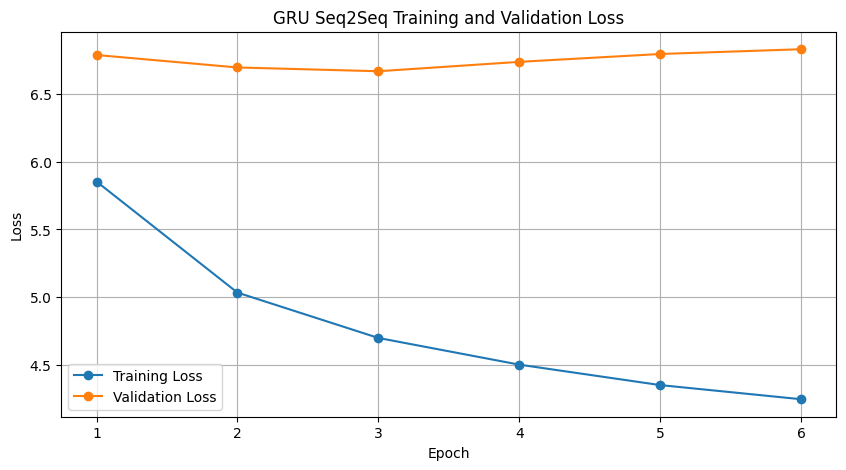

Saved to:
/content/drive/MyDrive/NNDL_English_Hindi_Translator/results/plots/gru_seq2seq_loss_curve.png


In [35]:
# ============================================================
# STEP 41: SAVE TRAINING LOSS CURVE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, 7),
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    range(1, 7),
    validation_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(
    "GRU Seq2Seq Training and Validation Loss"
)

plt.legend()
plt.grid(True)

GRU_LOSS_PLOT_PATH = os.path.join(
    RESULTS_PLOTS_DIR,
    "gru_seq2seq_loss_curve.png"
)

plt.savefig(
    GRU_LOSS_PLOT_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved to:")
print(GRU_LOSS_PLOT_PATH)